In [ ]:
from google.colab import files
upload=files.upload()

Saving iris.csv to iris.csv


In [ ]:
import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
from sklearn import tree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
iris_pdf=pd.read_csv("iris.csv")
iris_pdf.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris_pdf.isnull().any()

,0
sepal_length,False
sepal_width,False
petal_length,False
petal_width,False
species,False


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

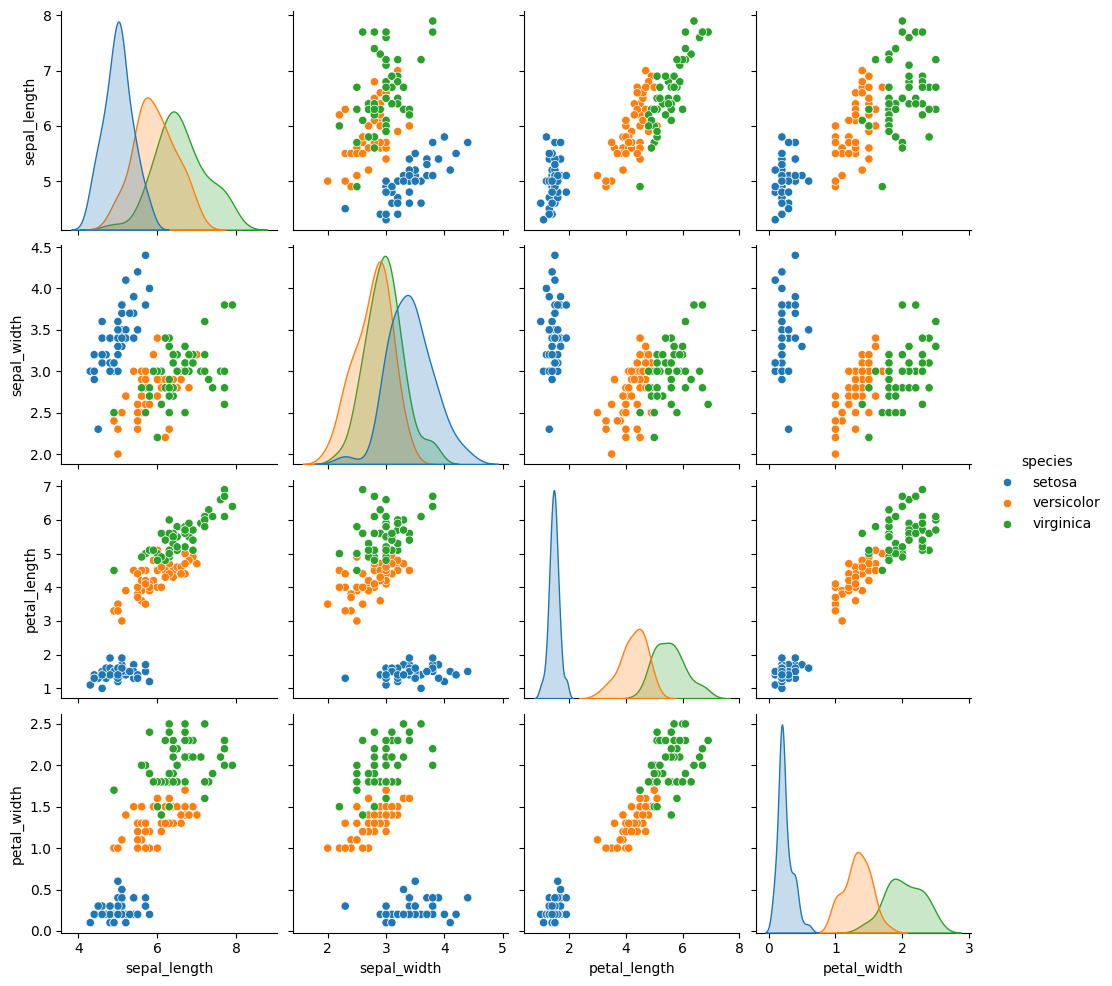

In [ ]:
sns.pairplot(iris_pdf,hue="species")
plt.savefig("exercise2a.png")
files.download("exercise2a.png")

In [ ]:
X=iris_pdf[['sepal_length','sepal_width','petal_length','petal_width']].values
Y=iris_pdf['species'].values
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.9,random_state=1,stratify=Y)
print(f"Training shapes:{X_train.shape},{Y_train.shape}")
print(f"Testing shapes:{X_test.shape},{Y_test.shape}")

Training shapes:(135, 4),(135,)
Testing shapes:(15, 4),(15,)


In [ ]:
clf=tree.DecisionTreeClassifier()
clf=clf.fit(X_train,Y_train)

In [ ]:
prediction=clf.predict(X_test)
prediction

array(['versicolor', 'versicolor', 'virginica', 'setosa', 'versicolor',
       'setosa', 'setosa', 'virginica', 'versicolor', 'virginica',
       'setosa', 'versicolor', 'versicolor', 'virginica', 'setosa'],
      dtype=object)

In [ ]:
print(classification_report(Y_test,prediction))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       0.83      1.00      0.91         5
   virginica       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.94      0.93      0.93        15
weighted avg       0.94      0.93      0.93        15



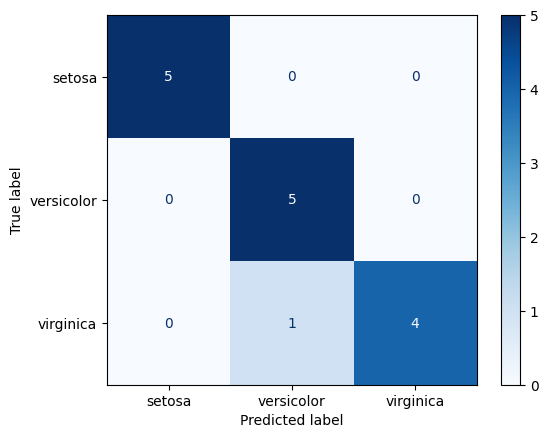

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from google.colab import files
import matplotlib.pyplot as plt
disp=ConfusionMatrixDisplay.from_estimator(clf,X_test,Y_test,cmap=plt.cm.Blues)
plt.savefig("exercise2b.png",bbox_inches='tight',dpi=300)
plt.show()
files.download("exercise2b.png")

In [ ]:
!pip install pydotplus
!apt-get install grapheriz-y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package grapheriz-y


In [ ]:
# Install Graphviz (Run this once in Google Colab)
!apt-get -qq install graphviz
!pip install graphviz pydotplus

from io import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
from google.colab import files

# Create DOT data
dot_data = StringIO()

export_graphviz(
    clf,   # Your trained Decision Tree model
    out_file=dot_data,
    feature_names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
    class_names=[str(c) for c in clf.classes_],
    filled=True,
    rounded=True,
    special_characters=True
)

# Generate graph
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

# Save as PNG
graph.write_png("exercise2c.png")

# Display the image
Image("exercise2c.png")

# Download the image
files.download("exercise2c.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sepal_length=4.8
sepal_width=2.9
petal_length=1.3
petal_width=0.2
x=[[sepal_length,sepal_width,petal_length,petal_width]]
res=clf.predict(x)
print("The class predicted is -->"+str(res[0]))

The class predicted is -->setosa


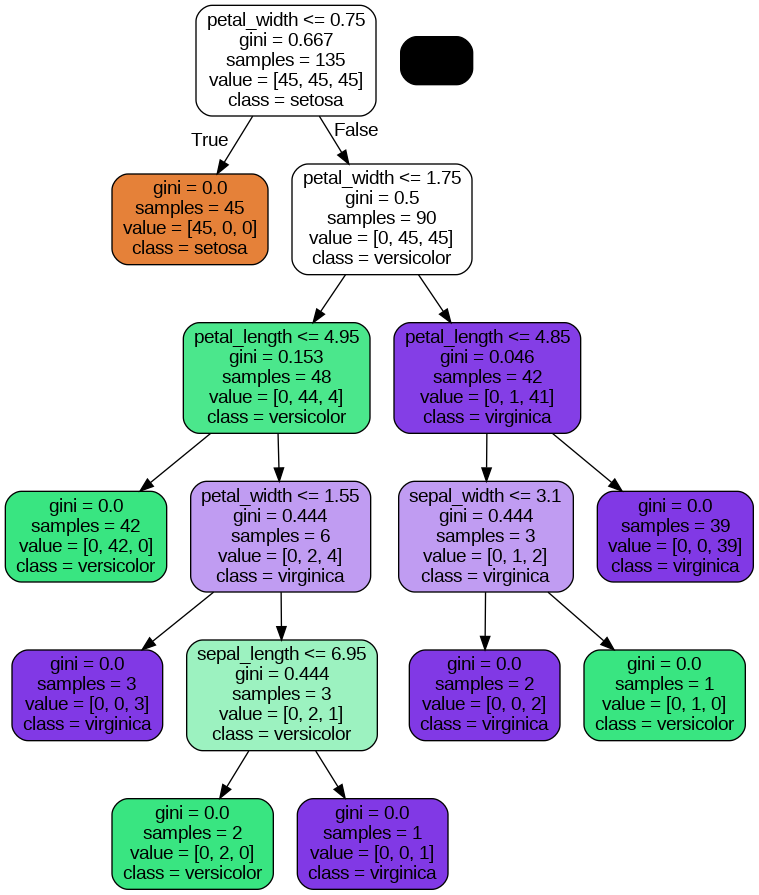

In [ ]:
from io import StringIO
from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image

dot_data = StringIO()

export_graphviz(
    clf,
    out_file=dot_data,
    feature_names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
    class_names=['setosa', 'versicolor', 'virginica'],
    filled=True,
    rounded=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())